In [39]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.stats as stats

import nibabel as nib
import nilearn.connectome as nic
import nilearn.plotting as plotting
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import hcp_utils as hcp
from collections import Counter



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_recall_curve, balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Input, Concatenate, BatchNormalization, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model



import tensorflow as tf
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.combine import SMOTETomek

from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
from scipy.stats import pearsonr

## d15

In [40]:
from nilearn import image, plotting
from atlasreader.atlasreader import read_atlas_peak

# """
# available reference atlases
# ---------------------------
#     "aal",
#     "aicha",
#     "desikan_killiany",
#     "destrieux",
#     "harvard_oxford",
#     "juelich",
#     "marsatlas",
#     "neuromorphometrics",
#     "talairach_ba",
#     "talairach_gyrus",
#  """

# atlas = image.threshold_img("HCP_PTN1200/groupICA/groupICA_3T_HCP1200_MSMAll_d15.ica/melodic_IC_sum.nii.gz", "99.5%") 
# atlas_coords = plotting.find_probabilistic_atlas_cut_coords(atlas)
# brain_region = []
# print("BRAIN REGIONS:\n--------------")
# for atlas_coord in atlas_coords:
#     region = read_atlas_peak("harvard_oxford", atlas_coord)
#     print(region)
#     brain_region += [region]

# brain_region = [
#     max(inner_list, key=lambda x: x[0])[-1] if inner_list else None for inner_list in brain_region
# ]

open_access_data = pd.read_csv("unrestricted_data.csv")
restricted_data = pd.read_csv("RESTRICTED_BEHAVIORAL_DATA.csv")
subject_data = open_access_data.merge(restricted_data, how = 'inner', on = 'Subject')

folder = 'HCP_PTN1200/node_timeseries/3T_HCP1200_MSMAll_d15_ts2'
brain_files = [f for f in os.listdir(folder) if f.endswith('.txt')]
brain_data = {}

for filename in brain_files:
    subject_id = int(filename[:6])
    file_path = os.path.join(folder, filename)
    subject_brain_data = np.loadtxt(file_path)
    brain_data[subject_id] = subject_brain_data

brain_data_df = pd.DataFrame({
    'Subject': list(brain_data.keys()),
    'Brain_Data': list(brain_data.values())  # (4800, 100) arrays
})
brain_data_df

data = subject_data.merge(brain_data_df, on='Subject', how='inner')

#Correlation matrix
correlation_measure = nic.ConnectivityMeasure(kind='partial correlation')
correlation_matrix = correlation_measure.fit_transform(data["Brain_Data"])
handedness = data["Handedness"]

#replace 1.0 with np.nan correlations
copy_matrix = correlation_matrix.copy()
copy_matrix[copy_matrix == 1.00] = np.nan

fisher_z_matrices = np.arctanh(copy_matrix)

#function to find significant correlations
def sig_pvals(fisher_z_matrices):
    corr_mat = {}
    pval_mat = {}
    count_pval = 0
    matrix_dim = fisher_z_matrices.shape
    for i in range(matrix_dim[1]):
        for j in range(i, matrix_dim[1]):
            if i != j:
                corr, pval = stats.pearsonr(fisher_z_matrices[:,i, j],  handedness)
                corr_mat[(i, j)] = corr
                pval_mat[(i,j)] = pval
                if abs(pval) < 0.05:
                    # print(f'pair ({i}, {j}) has a pval of {pval}')
                    count_pval += 1
    print(count_pval)
    return corr_mat, pval_mat
    
#find strongest negative correlation
corr_mat, pval_mat = sig_pvals(fisher_z_matrices)

sorted_keys = sorted(corr_mat, key=lambda x: corr_mat[x])

order = 0 # this corresponds to the sorted order, so 0 is the 1st values in the sorted keys
#you can use this to find top 10 regions, and bottom 10 regions

# Extract top 10 positively correlated regions
top_10_15 = {i: (region, corr_mat[region]) for i, region in enumerate(sorted_keys[-10:])}

# Extract bottom 10 negatively correlated regions
bottom_10_15 = {i: (region, corr_mat[region]) for i, region in enumerate(sorted_keys[:10])}



27


In [41]:
# Print results
print("Top 10 positively correlated regions:")
print(top_10_15)

print("\nBottom 10 negatively correlated regions:")
print(bottom_10_15)

Top 10 positively correlated regions:
{0: ((0, 5), 0.0725099426151914), 1: ((1, 13), 0.07291133888023706), 2: ((2, 7), 0.0808061538179942), 3: ((4, 7), 0.08105595616173973), 4: ((2, 6), 0.08669301650428897), 5: ((4, 10), 0.08717775774734635), 6: ((1, 9), 0.09752738279358854), 7: ((0, 7), 0.09953178192721208), 8: ((11, 13), 0.10062133755979012), 9: ((6, 14), 0.11681610045569638)}

Bottom 10 negatively correlated regions:
{0: ((1, 6), -0.14905114851325704), 1: ((13, 14), -0.12706239473989764), 2: ((6, 9), -0.11805100816425675), 3: ((4, 14), -0.09817306212947348), 4: ((1, 14), -0.09731592960442402), 5: ((4, 6), -0.09140792758778085), 6: ((3, 8), -0.08959069522277965), 7: ((9, 12), -0.08493586473314492), 8: ((8, 9), -0.08419922351172265), 9: ((6, 11), -0.08399253174928664)}


## d25

In [42]:
# atlas = image.threshold_img("HCP_PTN1200/groupICA/groupICA_3T_HCP1200_MSMAll_d25.ica/melodic_IC_sum.nii.gz", "99.5%") 
# atlas_coords = plotting.find_probabilistic_atlas_cut_coords(atlas)
# brain_region = []
# print("BRAIN REGIONS:\n--------------")
# for atlas_coord in atlas_coords:
#     region = read_atlas_peak("harvard_oxford", atlas_coord)
#     print(region)
#     brain_region += [region]

# brain_region = [
#     max(inner_list, key=lambda x: x[0])[-1] if inner_list else None for inner_list in brain_region
# ]

open_access_data = pd.read_csv("unrestricted_data.csv")
restricted_data = pd.read_csv("RESTRICTED_BEHAVIORAL_DATA.csv")
subject_data = open_access_data.merge(restricted_data, how = 'inner', on = 'Subject')

folder = 'HCP_PTN1200/node_timeseries/3T_HCP1200_MSMAll_d25_ts2'
brain_files = [f for f in os.listdir(folder) if f.endswith('.txt')]
brain_data = {}

for filename in brain_files:
    subject_id = int(filename[:6])
    file_path = os.path.join(folder, filename)
    subject_brain_data = np.loadtxt(file_path)
    brain_data[subject_id] = subject_brain_data

brain_data_df = pd.DataFrame({
    'Subject': list(brain_data.keys()),
    'Brain_Data': list(brain_data.values())  # (4800, 100) arrays
})
brain_data_df

data = subject_data.merge(brain_data_df, on='Subject', how='inner')

#Correlation matrix
correlation_measure = nic.ConnectivityMeasure(kind='partial correlation')
correlation_matrix = correlation_measure.fit_transform(data["Brain_Data"])
handedness = data["Handedness"]

#replace 1.0 with np.nan correlations
copy_matrix = correlation_matrix.copy()
copy_matrix[copy_matrix == 1.00] = np.nan

fisher_z_matrices = np.arctanh(copy_matrix)

#function to find significant correlations
def sig_pvals(fisher_z_matrices):
    corr_mat = {}
    pval_mat = {}
    count_pval = 0
    matrix_dim = fisher_z_matrices.shape
    for i in range(matrix_dim[1]):
        for j in range(i, matrix_dim[1]):
            if i != j:
                corr, pval = stats.pearsonr(fisher_z_matrices[:,i, j],  handedness)
                corr_mat[(i, j)] = corr
                pval_mat[(i,j)] = pval
                if abs(pval) < 0.05:
                    # print(f'pair ({i}, {j}) has a pval of {pval}')
                    count_pval += 1
    print(count_pval)
    return corr_mat, pval_mat
    
#find strongest negative correlation
corr_mat, pval_mat = sig_pvals(fisher_z_matrices)

sorted_keys = sorted(corr_mat, key=lambda x: corr_mat[x])

order = 0 # this corresponds to the sorted order, so 0 is the 1st values in the sorted keys
#you can use this to find top 10 regions, and bottom 10 regions

# Extract top 10 positively correlated regions
top_10_25 = {i: (region, corr_mat[region]) for i, region in enumerate(sorted_keys[-10:])}

# Extract bottom 10 negatively correlated regions
bottom_10_25 = {i: (region, corr_mat[region]) for i, region in enumerate(sorted_keys[:10])}



53


In [43]:
# Print results
print("Top 10 positively correlated regions:")
print(top_10_25)

print("\nBottom 10 negatively correlated regions:")
print(bottom_10_25)

Top 10 positively correlated regions:
{0: ((0, 1), 0.09283609002937492), 1: ((15, 17), 0.09380915323997023), 2: ((4, 19), 0.09456117123343877), 3: ((10, 17), 0.09951937459932121), 4: ((2, 8), 0.10124135728866704), 5: ((1, 5), 0.1072110332878483), 6: ((7, 20), 0.11152827569317068), 7: ((6, 7), 0.11403041816970237), 8: ((16, 20), 0.11674994686692791), 9: ((5, 17), 0.134231017787869)}

Bottom 10 negatively correlated regions:
{0: ((17, 20), -0.20972235887897941), 1: ((1, 4), -0.1925262413790798), 2: ((15, 16), -0.15962104514888123), 3: ((4, 11), -0.13331267553962894), 4: ((16, 17), -0.1233567351683499), 5: ((4, 17), -0.11927131444917835), 6: ((18, 19), -0.11446446726939606), 7: ((5, 13), -0.09142634906188585), 8: ((9, 21), -0.09109867651292498), 9: ((1, 20), -0.08952356211119517)}


## d50

In [44]:
# atlas = image.threshold_img("HCP_PTN1200/groupICA/groupICA_3T_HCP1200_MSMAll_d50.ica/melodic_IC_sum.nii.gz", "99.5%") 
# atlas_coords = plotting.find_probabilistic_atlas_cut_coords(atlas)
# brain_region = []
# for atlas_coord in atlas_coords:
#     region = read_atlas_peak("harvard_oxford", atlas_coord)
#     brain_region += [region]

# brain_region = [
#     max(inner_list, key=lambda x: x[0])[-1] if inner_list else None for inner_list in brain_region
# ]

open_access_data = pd.read_csv("unrestricted_data.csv")
restricted_data = pd.read_csv("RESTRICTED_BEHAVIORAL_DATA.csv")
subject_data = open_access_data.merge(restricted_data, how = 'inner', on = 'Subject')

folder = 'HCP_PTN1200/node_timeseries/3T_HCP1200_MSMAll_d50_ts2'
brain_files = [f for f in os.listdir(folder) if f.endswith('.txt')]
brain_data = {}

for filename in brain_files:
    subject_id = int(filename[:6])
    file_path = os.path.join(folder, filename)
    subject_brain_data = np.loadtxt(file_path)
    brain_data[subject_id] = subject_brain_data

brain_data_df = pd.DataFrame({
    'Subject': list(brain_data.keys()),
    'Brain_Data': list(brain_data.values())  # (4800, 100) arrays
})
brain_data_df

data = subject_data.merge(brain_data_df, on='Subject', how='inner')

#Correlation matrix
correlation_measure = nic.ConnectivityMeasure(kind='partial correlation')
correlation_matrix = correlation_measure.fit_transform(data["Brain_Data"])
handedness = data["Handedness"]

#replace 1.0 with np.nan correlations
copy_matrix = correlation_matrix.copy()
copy_matrix[copy_matrix == 1.00] = np.nan

fisher_z_matrices = np.arctanh(copy_matrix)

#function to find significant correlations
def sig_pvals(fisher_z_matrices):
    corr_mat = {}
    pval_mat = {}
    count_pval = 0
    matrix_dim = fisher_z_matrices.shape
    for i in range(matrix_dim[1]):
        for j in range(i, matrix_dim[1]):
            if i != j:
                corr, pval = stats.pearsonr(fisher_z_matrices[:,i, j],  handedness)
                corr_mat[(i, j)] = corr
                pval_mat[(i,j)] = pval
                if abs(pval) < 0.05:
                    # print(f'pair ({i}, {j}) has a pval of {pval}')
                    count_pval += 1
    print(count_pval)
    return corr_mat, pval_mat
    
#find strongest negative correlation
corr_mat, pval_mat = sig_pvals(fisher_z_matrices)

sorted_keys = sorted(corr_mat, key=lambda x: corr_mat[x])

order = 0 # this corresponds to the sorted order, so 0 is the 1st values in the sorted keys
#you can use this to find top 10 regions, and bottom 10 regions

# Extract top 10 positively correlated regions
top_10_50 = {i: (region, corr_mat[region]) for i, region in enumerate(sorted_keys[-10:])}

# Extract bottom 10 negatively correlated regions
bottom_10_50 = {i: (region, corr_mat[region]) for i, region in enumerate(sorted_keys[:10])}


158


In [45]:
# Print results
print("Top 10 positively correlated regions:")
print(top_10_50)

print("\nBottom 10 negatively correlated regions:")
print(bottom_10_50)

Top 10 positively correlated regions:
{0: ((5, 9), 0.09745542596193267), 1: ((6, 40), 0.09835641795769616), 2: ((4, 18), 0.10477410418142308), 3: ((9, 22), 0.10566669463648735), 4: ((11, 16), 0.10664420864454377), 5: ((14, 25), 0.10925624533881413), 6: ((6, 16), 0.11674098799471024), 7: ((4, 43), 0.14199963894195922), 8: ((4, 11), 0.1609180066971379), 9: ((8, 29), 0.22122812737334765)}

Bottom 10 negatively correlated regions:
{0: ((8, 14), -0.1874839689147712), 1: ((6, 29), -0.18499521837750355), 2: ((11, 27), -0.17898953524561917), 3: ((25, 29), -0.1744427818775452), 4: ((6, 22), -0.1348920605228005), 5: ((9, 18), -0.13172455881315995), 6: ((17, 28), -0.12773345206288395), 7: ((14, 26), -0.12653343131146083), 8: ((9, 11), -0.12498840867346121), 9: ((4, 47), -0.1248568822835001)}


## d100

In [46]:
# atlas = image.threshold_img("HCP_PTN1200/groupICA/groupICA_3T_HCP1200_MSMAll_d100.ica/melodic_IC_sum.nii.gz", "99.5%") 
# atlas_coords = plotting.find_probabilistic_atlas_cut_coords(atlas)
# brain_region = []
# for atlas_coord in atlas_coords:
#     region = read_atlas_peak("harvard_oxford", atlas_coord)
#     brain_region += [region]

# brain_region = [
#     max(inner_list, key=lambda x: x[0])[-1] if inner_list else None for inner_list in brain_region
# ]

open_access_data = pd.read_csv("unrestricted_data.csv")
restricted_data = pd.read_csv("RESTRICTED_BEHAVIORAL_DATA.csv")
subject_data = open_access_data.merge(restricted_data, how = 'inner', on = 'Subject')

folder = 'HCP_PTN1200/node_timeseries/3T_HCP1200_MSMAll_d100_ts2'
brain_files = [f for f in os.listdir(folder) if f.endswith('.txt')]
brain_data = {}

for filename in brain_files:
    subject_id = int(filename[:6])
    file_path = os.path.join(folder, filename)
    subject_brain_data = np.loadtxt(file_path)
    brain_data[subject_id] = subject_brain_data

brain_data_df = pd.DataFrame({
    'Subject': list(brain_data.keys()),
    'Brain_Data': list(brain_data.values())  # (4800, 100) arrays
})
brain_data_df

data = subject_data.merge(brain_data_df, on='Subject', how='inner')

#Correlation matrix
correlation_measure = nic.ConnectivityMeasure(kind='partial correlation')
correlation_matrix = correlation_measure.fit_transform(data["Brain_Data"])
handedness = data["Handedness"]

#replace 1.0 with np.nan correlations
copy_matrix = correlation_matrix.copy()
copy_matrix[copy_matrix == 1.00] = np.nan

fisher_z_matrices = np.arctanh(copy_matrix)

#function to find significant correlations
def sig_pvals(fisher_z_matrices):
    corr_mat = {}
    pval_mat = {}
    count_pval = 0
    matrix_dim = fisher_z_matrices.shape
    for i in range(matrix_dim[1]):
        for j in range(i, matrix_dim[1]):
            if i != j:
                corr, pval = stats.pearsonr(fisher_z_matrices[:,i, j],  handedness)
                corr_mat[(i, j)] = corr
                pval_mat[(i,j)] = pval
                if abs(pval) < 0.05:
                    # print(f'pair ({i}, {j}) has a pval of {pval}')
                    count_pval += 1
    print(count_pval)
    return corr_mat, pval_mat
    
#find strongest negative correlation
corr_mat, pval_mat = sig_pvals(fisher_z_matrices)

sorted_keys = sorted(corr_mat, key=lambda x: corr_mat[x])

order = 0 # this corresponds to the sorted order, so 0 is the 1st values in the sorted keys
#you can use this to find top 10 regions, and bottom 10 regions

# Extract top 10 positively correlated regions
top_10_100 = {i: (region, corr_mat[region]) for i, region in enumerate(sorted_keys[-10:])}

# Extract bottom 10 negatively correlated regions
bottom_10_100 = {i: (region, corr_mat[region]) for i, region in enumerate(sorted_keys[:10])}


526


In [47]:
# Print results
print("Top 10 positively correlated regions:")
print(top_10_100)

print("\nBottom 10 negatively correlated regions:")
print(bottom_10_100)

Top 10 positively correlated regions:
{0: ((69, 88), 0.11608741842214099), 1: ((35, 60), 0.11821856254829538), 2: ((32, 43), 0.12142474048460769), 3: ((27, 73), 0.12222790279194845), 4: ((11, 21), 0.12301669770621447), 5: ((9, 30), 0.12468961965188169), 6: ((8, 17), 0.13223619982573737), 7: ((8, 26), 0.13256829499617837), 8: ((13, 43), 0.15120539471539604), 9: ((4, 30), 0.21869769034516395)}

Bottom 10 negatively correlated regions:
{0: ((30, 41), -0.1430323975890052), 1: ((4, 36), -0.1418758001191596), 2: ((6, 13), -0.14088545265706862), 3: ((11, 32), -0.14072250269513467), 4: ((7, 35), -0.13484064252474448), 5: ((30, 36), -0.1305319507184919), 6: ((1, 22), -0.11359630250493527), 7: ((40, 77), -0.11337795764496701), 8: ((35, 57), -0.11034212350850382), 9: ((13, 28), -0.11007074347663287)}


## d200

In [48]:
# atlas = image.threshold_img("HCP_PTN1200/groupICA/groupICA_3T_HCP1200_MSMAll_d200.ica/melodic_IC_sum.nii.gz", "99.5%") 
# atlas_coords = plotting.find_probabilistic_atlas_cut_coords(atlas)
# brain_region = []
# for atlas_coord in atlas_coords:
#     region = read_atlas_peak("harvard_oxford", atlas_coord)
#     brain_region += [region]

# brain_region = [
#     max(inner_list, key=lambda x: x[0])[-1] if inner_list else None for inner_list in brain_region
# ]

open_access_data = pd.read_csv("unrestricted_data.csv")
restricted_data = pd.read_csv("RESTRICTED_BEHAVIORAL_DATA.csv")
subject_data = open_access_data.merge(restricted_data, how = 'inner', on = 'Subject')

folder = 'HCP_PTN1200/node_timeseries/3T_HCP1200_MSMAll_d200_ts2'
brain_files = [f for f in os.listdir(folder) if f.endswith('.txt')]
brain_data = {}

for filename in brain_files:
    subject_id = int(filename[:6])
    file_path = os.path.join(folder, filename)
    subject_brain_data = np.loadtxt(file_path)
    brain_data[subject_id] = subject_brain_data

brain_data_df = pd.DataFrame({
    'Subject': list(brain_data.keys()),
    'Brain_Data': list(brain_data.values())  # (4800, 100) arrays
})
brain_data_df

data = subject_data.merge(brain_data_df, on='Subject', how='inner')

#Correlation matrix
correlation_measure = nic.ConnectivityMeasure(kind='partial correlation')
correlation_matrix = correlation_measure.fit_transform(data["Brain_Data"])
handedness = data["Handedness"]

#replace 1.0 with np.nan correlations
copy_matrix = correlation_matrix.copy()
copy_matrix[copy_matrix == 1.00] = np.nan

fisher_z_matrices = np.arctanh(copy_matrix)

#function to find significant correlations
def sig_pvals(fisher_z_matrices):
    corr_mat = {}
    pval_mat = {}
    count_pval = 0
    matrix_dim = fisher_z_matrices.shape
    for i in range(matrix_dim[1]):
        for j in range(i, matrix_dim[1]):
            if i != j:
                corr, pval = stats.pearsonr(fisher_z_matrices[:,i, j],  handedness)
                corr_mat[(i, j)] = corr
                pval_mat[(i,j)] = pval
                if abs(pval) < 0.05:
                    # print(f'pair ({i}, {j}) has a pval of {pval}')
                    count_pval += 1
    print(count_pval)
    return corr_mat, pval_mat
    
#find strongest negative correlation
corr_mat, pval_mat = sig_pvals(fisher_z_matrices)

sorted_keys = sorted(corr_mat, key=lambda x: corr_mat[x])

order = 0 # this corresponds to the sorted order, so 0 is the 1st values in the sorted keys
#you can use this to find top 10 regions, and bottom 10 regions

# Extract top 10 positively correlated regions
top_10_200 = {i: (region, corr_mat[region]) for i, region in enumerate(sorted_keys[-10:])}

# Extract bottom 10 negatively correlated regions
bottom_10_200 = {i: (region, corr_mat[region]) for i, region in enumerate(sorted_keys[:10])}


1450


In [49]:
# Print results
print("Top 10 positively correlated regions:")
print(top_10_200)

print("\nBottom 10 negatively correlated regions:")
print(bottom_10_200)

Top 10 positively correlated regions:
{0: ((20, 128), 0.12398282687620872), 1: ((55, 101), 0.12432193547962019), 2: ((51, 55), 0.1248529339217189), 3: ((135, 167), 0.12560830531454026), 4: ((26, 40), 0.13212531795570423), 5: ((15, 49), 0.13233134388784348), 6: ((12, 51), 0.1396824018877181), 7: ((51, 58), 0.14417954263545246), 8: ((4, 26), 0.15479091803318723), 9: ((33, 133), 0.1859613598162929)}

Bottom 10 negatively correlated regions:
{0: ((9, 18), -0.16067580289915706), 1: ((5, 51), -0.14482688917551162), 2: ((38, 51), -0.13831306431140122), 3: ((33, 155), -0.1286359948299229), 4: ((3, 15), -0.12766574612348788), 5: ((89, 98), -0.1259031033496435), 6: ((18, 51), -0.12515523115731708), 7: ((39, 51), -0.12478479730194146), 8: ((57, 85), -0.1244988535985898), 9: ((118, 169), -0.12171038355925483)}


## d300

In [50]:
# atlas = image.threshold_img("HCP_PTN1200/groupICA/groupICA_3T_HCP1200_MSMAll_d300.ica/melodic_IC_sum.nii.gz", "99.5%") 
# atlas_coords = plotting.find_probabilistic_atlas_cut_coords(atlas)
# brain_region = []
# for atlas_coord in atlas_coords:
#     region = read_atlas_peak("harvard_oxford", atlas_coord)
#     brain_region += [region]

# brain_region = [
#     max(inner_list, key=lambda x: x[0])[-1] if inner_list else None for inner_list in brain_region
# ]

open_access_data = pd.read_csv("unrestricted_data.csv")
restricted_data = pd.read_csv("RESTRICTED_BEHAVIORAL_DATA.csv")
subject_data = open_access_data.merge(restricted_data, how = 'inner', on = 'Subject')

folder = 'HCP_PTN1200/node_timeseries/3T_HCP1200_MSMAll_d300_ts2'
brain_files = [f for f in os.listdir(folder) if f.endswith('.txt')]
brain_data = {}

for filename in brain_files:
    subject_id = int(filename[:6])
    file_path = os.path.join(folder, filename)
    subject_brain_data = np.loadtxt(file_path)
    brain_data[subject_id] = subject_brain_data

brain_data_df = pd.DataFrame({
    'Subject': list(brain_data.keys()),
    'Brain_Data': list(brain_data.values())  # (4800, 100) arrays
})
brain_data_df

data = subject_data.merge(brain_data_df, on='Subject', how='inner')

#Correlation matrix
correlation_measure = nic.ConnectivityMeasure(kind='partial correlation')
correlation_matrix = correlation_measure.fit_transform(data["Brain_Data"])
handedness = data["Handedness"]

#replace 1.0 with np.nan correlations
copy_matrix = correlation_matrix.copy()
copy_matrix[copy_matrix == 1.00] = np.nan

fisher_z_matrices = np.arctanh(copy_matrix)

#function to find significant correlations
def sig_pvals(fisher_z_matrices):
    corr_mat = {}
    pval_mat = {}
    count_pval = 0
    matrix_dim = fisher_z_matrices.shape
    for i in range(matrix_dim[1]):
        for j in range(i, matrix_dim[1]):
            if i != j:
                corr, pval = stats.pearsonr(fisher_z_matrices[:,i, j],  handedness)
                corr_mat[(i, j)] = corr
                pval_mat[(i,j)] = pval
                if abs(pval) < 0.05:
                    # print(f'pair ({i}, {j}) has a pval of {pval}')
                    count_pval += 1
    print(count_pval)
    return corr_mat, pval_mat
    
#find strongest negative correlation
corr_mat, pval_mat = sig_pvals(fisher_z_matrices)

sorted_keys = sorted(corr_mat, key=lambda x: corr_mat[x])

order = 0 # this corresponds to the sorted order, so 0 is the 1st values in the sorted keys
#you can use this to find top 10 regions, and bottom 10 regions

# Extract top 10 positively correlated regions
top_10_300 = {i: (region, corr_mat[region]) for i, region in enumerate(sorted_keys[-10:])}

# Extract bottom 10 negatively correlated regions
bottom_10_300 = {i: (region, corr_mat[region]) for i, region in enumerate(sorted_keys[:10])}


3061


In [51]:
# Print results
print("Top 10 positively correlated regions:")
print(top_10_300)

print("\nBottom 10 negatively correlated regions:")
print(bottom_10_300)

Top 10 positively correlated regions:
{0: ((134, 214), 0.1309744318223289), 1: ((13, 58), 0.132928962525085), 2: ((67, 172), 0.13491893254512619), 3: ((21, 63), 0.1352857510310241), 4: ((44, 72), 0.14312593395436704), 5: ((126, 131), 0.14351931120398956), 6: ((38, 43), 0.14490498766344398), 7: ((30, 45), 0.14628393474693277), 8: ((23, 78), 0.16538118482511402), 9: ((30, 60), 0.1904597184156814)}

Bottom 10 negatively correlated regions:
{0: ((23, 63), -0.21267401809543135), 1: ((4, 23), -0.16906423430138268), 2: ((24, 38), -0.16139736266051827), 3: ((55, 72), -0.15379976426629927), 4: ((24, 60), -0.14843632559875264), 5: ((63, 172), -0.14198541368903297), 6: ((39, 58), -0.140546084713346), 7: ((21, 60), -0.13817194110046685), 8: ((59, 60), -0.1345548173676735), 9: ((74, 80), -0.12832322206199925)}


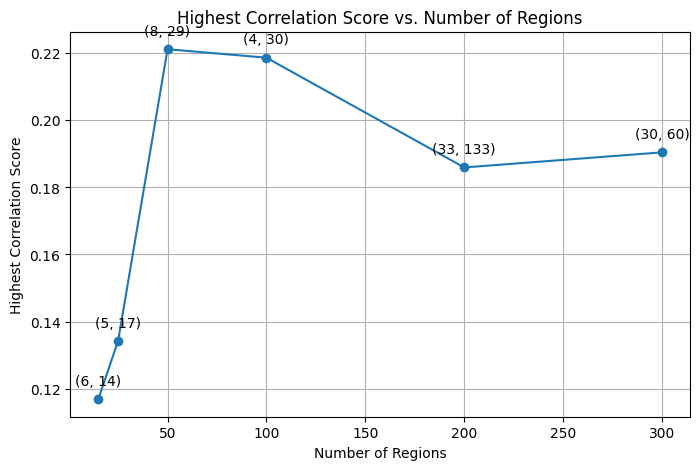

In [52]:
# Dictionary of highest correlation scores and corresponding region pairs for each region set
highest_correlations = {
    15: max(top_10_15.values(), key=lambda x: x[1]),
    25: max(top_10_25.values(), key=lambda x: x[1]),
    50: max(top_10_50.values(), key=lambda x: x[1]),
    100: max(top_10_100.values(), key=lambda x: x[1]),
    200: max(top_10_200.values(), key=lambda x: x[1]),
    300: max(top_10_300.values(), key=lambda x: x[1])
}

# Extract x (number of regions) and y (highest correlation scores)
x_values = list(highest_correlations.keys())
y_values = [val[1] for val in highest_correlations.values()]
labels = [str(val[0]) for val in highest_correlations.values()]  # Region pair names

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, marker='o', linestyle='-')

# Annotate each point with the corresponding region pair name
for i, txt in enumerate(labels):
    plt.annotate(txt, (x_values[i], y_values[i]), textcoords="offset points", xytext=(0, 10), ha='center')

# Labels and title
plt.xlabel("Number of Regions")
plt.ylabel("Highest Correlation Score")
plt.title("Highest Correlation Score vs. Number of Regions")
plt.grid(True)

# Show plot
plt.show()

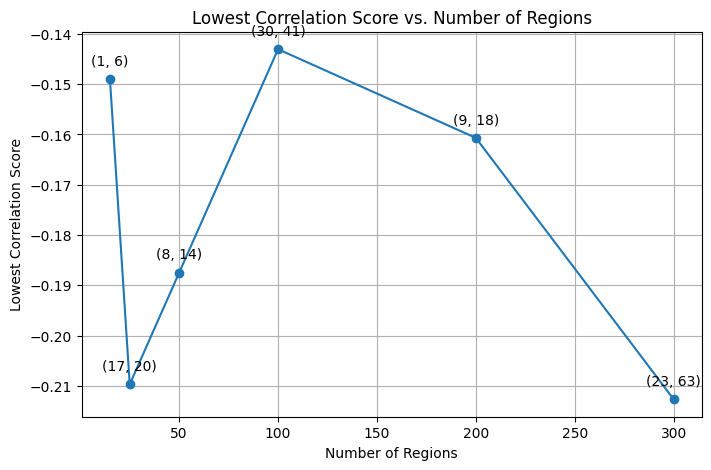

In [53]:
# Dictionary of highest correlation scores and corresponding region pairs for each region set
highest_correlations = {
    15: min(bottom_10_15.values(), key=lambda x: x[1]),
    25: min(bottom_10_25.values(), key=lambda x: x[1]),
    50: min(bottom_10_50.values(), key=lambda x: x[1]),
    100: min(bottom_10_100.values(), key=lambda x: x[1]),
    200: min(bottom_10_200.values(), key=lambda x: x[1]),
    300: min(bottom_10_300.values(), key=lambda x: x[1])
}

# Extract x (number of regions) and y (highest correlation scores)
x_values = list(highest_correlations.keys())
y_values = [val[1] for val in highest_correlations.values()]
labels = [str(val[0]) for val in highest_correlations.values()]  # Region pair names

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, marker='o', linestyle='-')

# Annotate each point with the corresponding region pair name
for i, txt in enumerate(labels):
    plt.annotate(txt, (x_values[i], y_values[i]), textcoords="offset points", xytext=(0, 10), ha='center')

# Labels and title
plt.xlabel("Number of Regions")
plt.ylabel("Lowest Correlation Score")
plt.title("Lowest Correlation Score vs. Number of Regions")
plt.grid(True)

# Show plot
plt.show()